# SDSS Stellar Classification: Exploratory Data Analysis

Sloan Digital Sky Survey DR17 (via Kaggle). Exploring the spectral and photometric properties of stars, galaxies, and quasars across 100,000 observations.

In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='darkgrid')
%matplotlib inline

df = pd.read_csv('../data/star_classification/star_classification.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (100000, 18)


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


In [147]:
# Check data types and null values
print(df.dtypes)
print(f"\nNull values:\n{df.isnull().sum()}")

obj_ID         float64
alpha          float64
delta          float64
u              float64
g              float64
r              float64
i              float64
z              float64
run_ID           int64
rerun_ID         int64
cam_col          int64
field_ID         int64
spec_obj_ID    float64
class              str
redshift       float64
plate            int64
MJD              int64
fiber_ID         int64
dtype: object

Null values:
obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64


In [148]:
# Class distribution
print(df['class'].value_counts())
print(f"\nClass proportions:\n{df['class'].value_counts(normalize=True).round(3)}")

class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64

Class proportions:
class
GALAXY    0.594
STAR      0.216
QSO       0.190
Name: proportion, dtype: float64


## Data Overview

The dataset contains 100,000 observations and 18 columns, sourced from the Sloan Digital Sky Survey DR17. All scientifically meaningful columns (`alpha`, `delta`, `u`, `g`, `r`, `i`, `z`, `redshift`) are stored as `float64`, confirming they are continuous numerical measurements. 

No null values were detected across any column. The dataset is complete and requires no additional cleaning.

### Class Distribution
| Class | Count | Proportion |
|-------|-------|------------|
| GALAXY | 59,445 | 59.4% |
| STAR | 21,594 | 21.6% |
| QSO | 18,961 | 19.0% |

Galaxies account for nearly 60% of all observations, creating a moderate class imbalance.

In [149]:
# Drop administratively irrelevant columns
cols_to_drop = ['obj_ID', 'run_ID', 'rerun_ID', 'cam_col', 
                'field_ID', 'spec_obj_ID', 'plate', 'MJD', 'fiber_ID']

df = df.drop(columns=cols_to_drop)
print(f"Remaining columns: {df.columns.tolist()}")
print(f"New shape: {df.shape}")

Remaining columns: ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'class', 'redshift']
New shape: (100000, 9)


## Data Preparation

9 administratively irrelevant columns were dropped (instrument IDs, scan identifiers, plate and fibre references). The working dataset retains 9 columns: sky coordinates (`alpha`, `delta`), photometric filters (`u`, `g`, `r`, `i`, `z`), `redshift`, and `class`.

In [150]:
# Descriptive statistics
df.describe().round(3)

,alpha,delta,u,g,r,i,z,redshift
count,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000,100000.000
mean,177.629,24.135,21.980,20.531,19.646,19.085,18.669,0.577
std,96.502,19.645,31.769,31.750,1.855,1.758,31.728,0.731
min,0.006,-18.785,-9999.000,-9999.000,9.822,9.470,-9999.000,-0.010
25%,127.518,5.147,20.352,18.965,18.136,17.732,17.461,0.055
50%,180.901,23.646,22.179,21.100,20.125,19.405,19.005,0.424
75%,233.895,39.902,23.687,22.124,21.045,20.396,19.921,0.704
max,360.000,83.001,32.781,31.602,29.572,32.141,29.384,7.011


## Visual Inspection of Preliminary Statistics

Coordinate ranges (`alpha`, `delta`) appear to be consistent with SDSS's northern sky coverage. Photometric results demonstrate presence of extreme values, i.e. `u`, `g`, `z` with minimums of -9999.0. These describe failed/missing measurements instead of real observations. 


In [151]:
# Investigate sentinel values
sentinel = -9999.0
filter_cols = ['u', 'g', 'r', 'i', 'z']

for col in filter_cols:
    count = (df[col] == sentinel).sum()
    print(f"{col}: {count} sentinel values")

u: 1 sentinel values
g: 1 sentinel values
r: 0 sentinel values
i: 0 sentinel values
z: 1 sentinel values


In [152]:
# Remove sentinel value rows
df = df[~(df[filter_cols] == sentinel).any(axis=1)]
print(f"Rows removed: {100000 - len(df)}")
print(f"New shape: {df.shape}")

Rows removed: 1
New shape: (99999, 9)


In [153]:
# Retrieve the removed row from the original data
original_df = pd.read_csv('../data/star_classification/star_classification.csv')
sentinel_mask = (original_df[filter_cols] == sentinel).any(axis=1)
print(original_df[sentinel_mask])

             obj_ID       alpha     delta       u       g        r         i  \
79543  1.237649e+18  224.006526 -0.624304 -9999.0 -9999.0  18.1656  18.01675   

            z  run_ID  rerun_ID  cam_col  field_ID   spec_obj_ID class  \
79543 -9999.0     752       301        2       537  3.731277e+18  STAR   

       redshift  plate    MJD  fiber_ID  
79543  0.000089   3314  54970       162  


## Analysing Failed Observation

Three of the five photometric filters failed on a single star observation, while two filters `r` and `i` recorded fine. This is consistent with detector or atmospheric issues affected the ends of the spectrum simultaneously. The SDSS SkyServer database can be queried directly to look what object sits at the resultant coordinates.

In [ ]:
from astroquery.sdss import SDSS 
from astropy import coordinates as coords
import astropy.units as u

pos = coords.SkyCoord(ra=224.006526, dec=-0.624304, unit='deg', frame='icrs')

result = SDSS.query_region(pos, radius=5*u.arcsec, spectro=True)
result.pprint_all()

       ra              dec                objid        run rerun camcol field      z       plate  mjd  fiberID      specobjid      run2d
--------------- ------------------ ------------------- --- ----- ------ ----- ------------ ----- ----- ------- ------------------- -----
224.00652611366 -0.624303881323656 1237648703521095984 752   301      2   537 8.934163e-05  3314 54970     162 3731276904880250880   104


In [155]:
objid = 1237648703521095984
url = f"https://skyserver.sdss.org/dr17/VisualTools/explore/summary?objid={objid}"
print(f"SDSS Object Explorer: {url}")

SDSS Object Explorer: https://skyserver.sdss.org/dr17/VisualTools/explore/summary?objid=1237648703521095984


## Anomalous Object Identification

The object has been identified as **SDSS J145601.56-003727.4**, observed on the 21st of March, 1999. EDGE flag noted in imaging flags, meaning the object was observed at the edge of the camera field, which may physically explain the filter failures. `PetroRad_r` of 1.04 arcseconds is consistent with a point source, demonstrating a star.

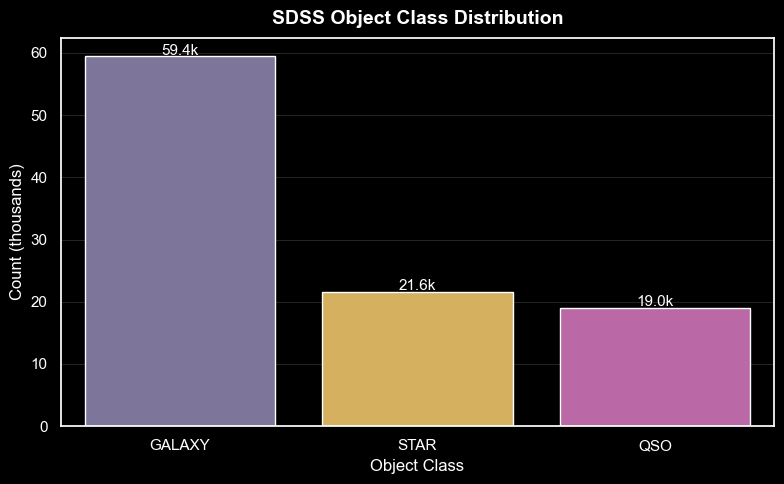

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5), facecolor='black')
ax.set_facecolor('black')

class_counts = df['class'].value_counts()

sns.barplot(x=class_counts.index, y=class_counts.values / 1000,
            palette=['#7B6FA0', '#E8B84B', '#C75BAD'],
            hue=class_counts.index, legend=False, ax=ax)

ax.set_title('SDSS Object Class Distribution', fontsize=14, 
             fontweight='bold', color='white', pad=10)
ax.set_xlabel('Object Class', fontsize=12, color='white')
ax.set_ylabel('Count (thousands)', fontsize=12, color='white')
ax.tick_params(colors='white')
ax.grid(color='#333333', linewidth=0.5, axis='y')

for spine in ax.spines.values():
    spine.set_edgecolor('white')

for i, v in enumerate(class_counts.values):
    ax.text(i, (v / 1000) + 0.3, f'{v/1000:.1f}k', 
            ha='center', fontsize=11, color='white')

plt.tight_layout()
plt.show()

## Object Class Distribution

In our dataset, objects classified as galaxies compose the clear majority of the data, at 59,445 counts. Stars and quasars are less numerous, comprising 21,594 and 18,961 respectively. 

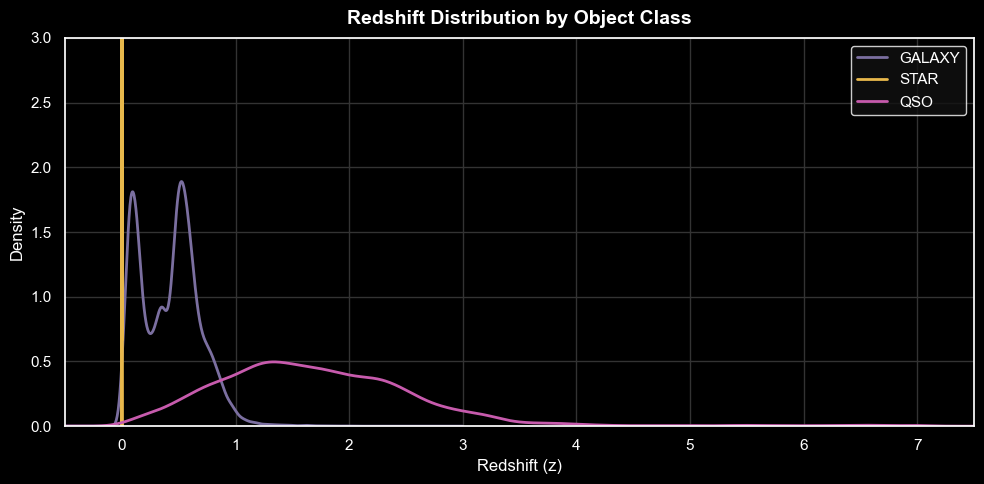

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5), facecolor='black')
ax.set_facecolor('black')

class_colours = {'GALAXY': '#7B6FA0', 'STAR': '#E8B84B', 'QSO': '#C75BAD'}

for cls, colour in class_colours.items():
    subset = df[df['class'] == cls]['redshift']
    subset.plot.kde(ax=ax, label=cls, color=colour, linewidth=2)

ax.set_title('Redshift Distribution by Object Class', fontsize=14, 
             fontweight='bold', color='white', pad=10)
ax.set_xlabel('Redshift (z)', fontsize=12, color='white')
ax.set_ylabel('Density', fontsize=12, color='white')
ax.set_xlim(-0.5, 7.5)
ax.set_ylim(0, 3)
ax.tick_params(colors='white')
ax.grid(color='#333333', linewidth=1)

for spine in ax.spines.values():
    spine.set_edgecolor('white')

legend = ax.legend(fontsize=11, facecolor='#111111', 
                   edgecolor='white', labelcolor='white')

plt.tight_layout()
plt.show()

## Redshift Distribution

The above graph demonstrates a few key findings from our data. Most evident is the near-vertical spike at z ≈ 0.0, caused by redshift originating from the STAR object class. Afterwards, a notable two-peak curve is illustrated by the redshift distribution of objects of the GALAXY class. Finally, a broad, flat distribution stretching between z ≈ 0.5 and z ≈ 7.0 is shown for objects under the QSO classification. These three distributions may be explained by the physical properties and distribution the data under analysis. 

1. Stars detected by the SDSS are local objects within our own galaxy, demonstrating essentially zero redshift. Y-axis (Density) had to be clipped for the purpose of data visualisation, as to show the wider trends of differing object classes.

2. Bimodal distribution of galaxies reflexts two populations at different distances, i.e. a nearby sample and a more distant survey. The SDSS deliberately targeted two populations, selected due to their brightness and ability to be detected at greater distances. These were named the Main Galaxy Sample (z ≈ 0.1) and the Luminous Red Galaxy Sample (z ≈ 0.4).
3. Quasars, being some of the oldest and most distant objects in the universe, have a larger distribution and as such vastly more counts with greater redshifts than other classifications. The peak around z ≈ 1.5 is consistent with the known epoch of peak quasar activity in cosmic history.

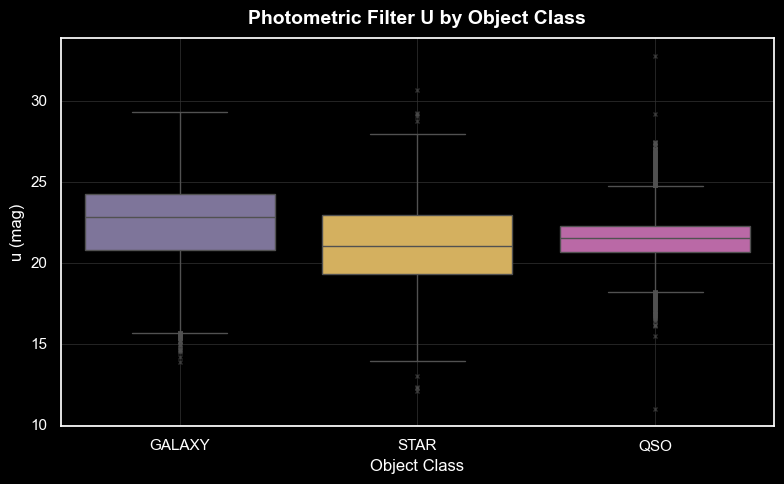

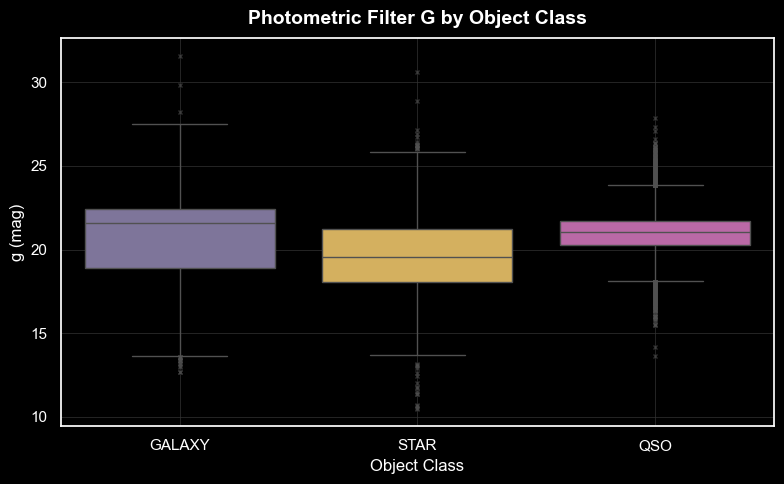

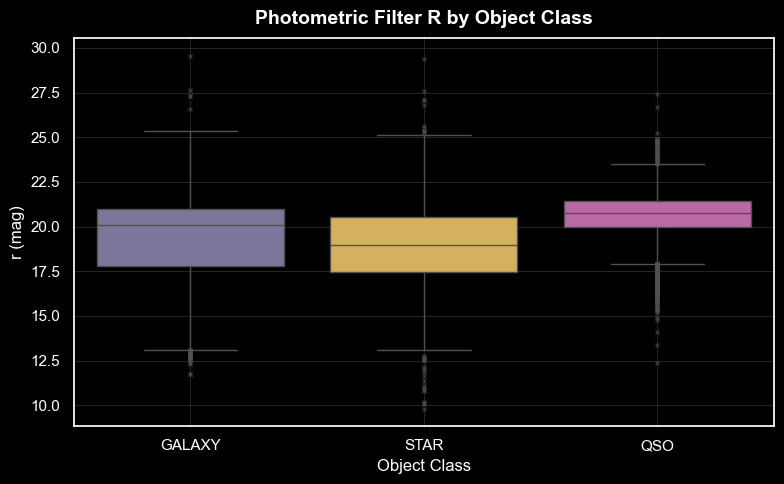

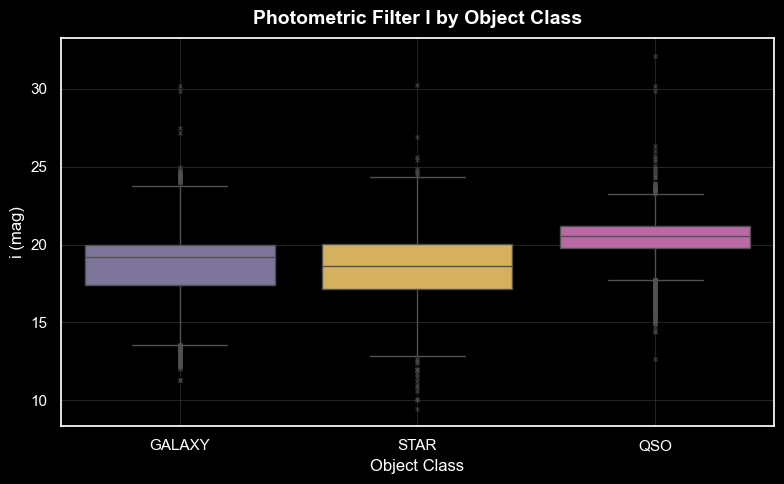

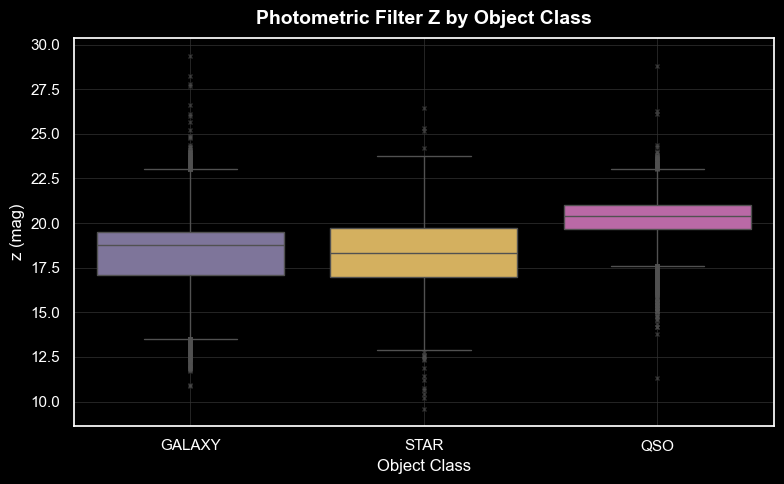

In [158]:
# Photometric filter distributions by class
filter_cols = ['u', 'g', 'r', 'i', 'z']
palette = {'GALAXY': '#7B6FA0', 'STAR': '#E8B84B', 'QSO': '#C75BAD'}

for filt in filter_cols:
    fig, ax = plt.subplots(figsize=(8, 5), facecolor='black')
    ax.set_facecolor('black')

    sns.boxplot(data=df, x='class', y=filt, hue='class',
                palette=palette, legend=False,
                order=['GALAXY', 'STAR', 'QSO'], ax=ax,
                flierprops=dict(marker='x', markersize=3, alpha=0.6, 
                                markerfacecolor='grey'))

    ax.set_title(f'Photometric Filter {filt.upper()} by Object Class',
                 fontsize=14, fontweight='bold', color='white', pad=10)
    ax.set_xlabel('Object Class', fontsize=12, color='white')
    ax.set_ylabel(f'{filt} (mag)', fontsize=12, color='white')
    ax.tick_params(colors='white')
    ax.grid(color='#333333', linewidth=0.5)

    for spine in ax.spines.values():
        spine.set_edgecolor('white')

    plt.tight_layout()
    plt.show()

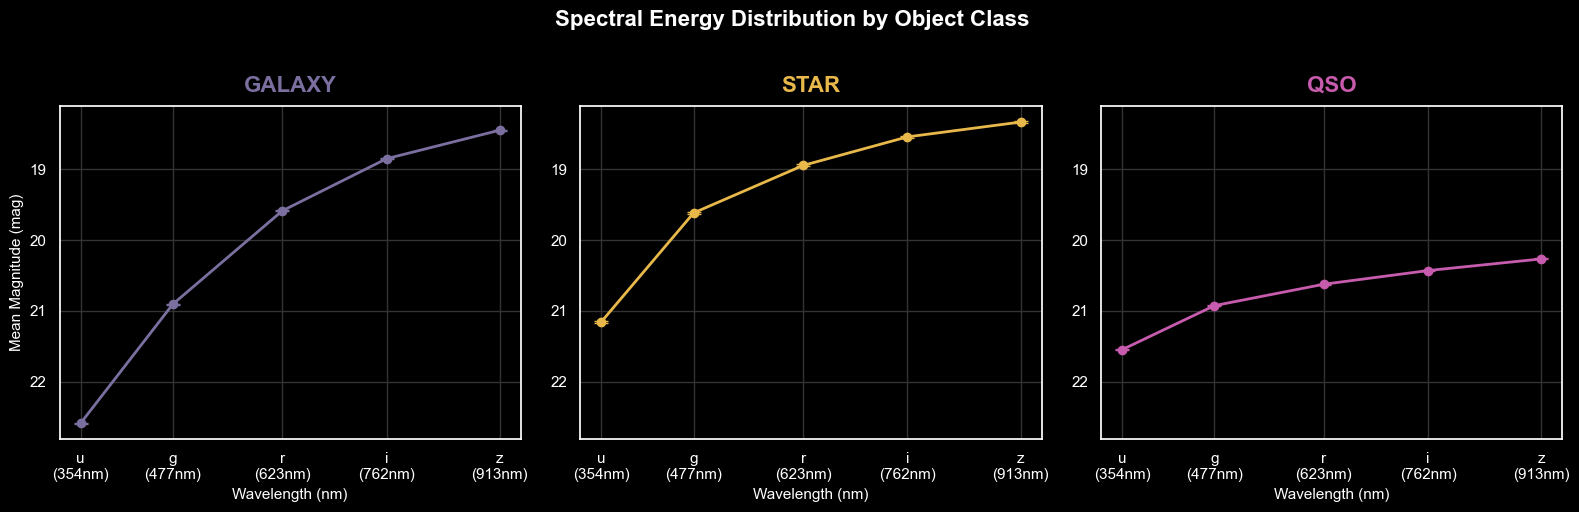

In [159]:
# Spectral Energy Distribution per Object Class
filter_wavelengths = {'u': 354, 'g': 477, 'r': 623, 'i': 762, 'z': 913}
filter_cols = list(filter_wavelengths.keys())
wavelengths = list(filter_wavelengths.values())
palette = {'GALAXY': '#7B6FA0', 'STAR': '#E8B84B', 'QSO': '#C75BAD'}
classes = ['GALAXY', 'STAR', 'QSO']

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True, facecolor='black')

for ax, cls in zip(axes, classes):
    ax.set_facecolor('black')
    subset = df[df['class'] == cls]
    means = [subset[f].mean() for f in filter_cols]
    sems = [subset[f].sem() for f in filter_cols]

    ax.yaxis.set_tick_params(labelleft=True)
    ax.errorbar(wavelengths, means, yerr=sems,
                color=palette[cls], linewidth=2,
                marker='o', markersize=6, capsize=5)

    ax.set_title(cls, fontsize=16, fontweight='bold', color=palette[cls], pad=10)
    ax.set_xlabel('Wavelength (nm)', fontsize=11, color='white')
    ax.set_xticks(wavelengths)
    ax.set_xticklabels([f'{f}\n({w}nm)' for f, w in filter_wavelengths.items()],
                       color='white')
    ax.tick_params(colors='white')
    ax.invert_yaxis()

    for spine in ax.spines.values():
        spine.set_edgecolor('white')
    
    ax.grid(color='#333333', linewidth=1)


axes[0].set_ylabel('Mean Magnitude (mag)', fontsize=11, color='white')

fig.suptitle('Spectral Energy Distribution by Object Class',
             fontsize=16, fontweight='bold', color='white', y=1.02)

plt.tight_layout()
plt.show()

## Comparison of SEDs between Object Classes

The three graphs produced allow for direct comparison of apparent magnitude between object classes. Here, the y-axis has been inverted, denoting greater brightness through higher resultant peaks. Stars exhibit largest overall brightness, particularly in the bluer filters. This is consistent with many hot, UV-luminous stellar types in the sample. Galaxies occupy the middle ground, with intermediate brightness in redder filters, and fainter brightness in the UV range. Finally, quasars are shown to be the faintest, despite their status as inherently the most luminous objects in the universe. This can be attributed by their distance from the observer. The above results demonstrate the distinction between intrinsic luminosity and apparent magnitude.

The relationship between apparent magnitude $m$ and luminosity is given by:

$$m = M + 5\log_{10}\left(\frac{d}{10\text{ pc}}\right)$$

where $M$ is the absolute magnitude and $d$ is the distance in parsecs.

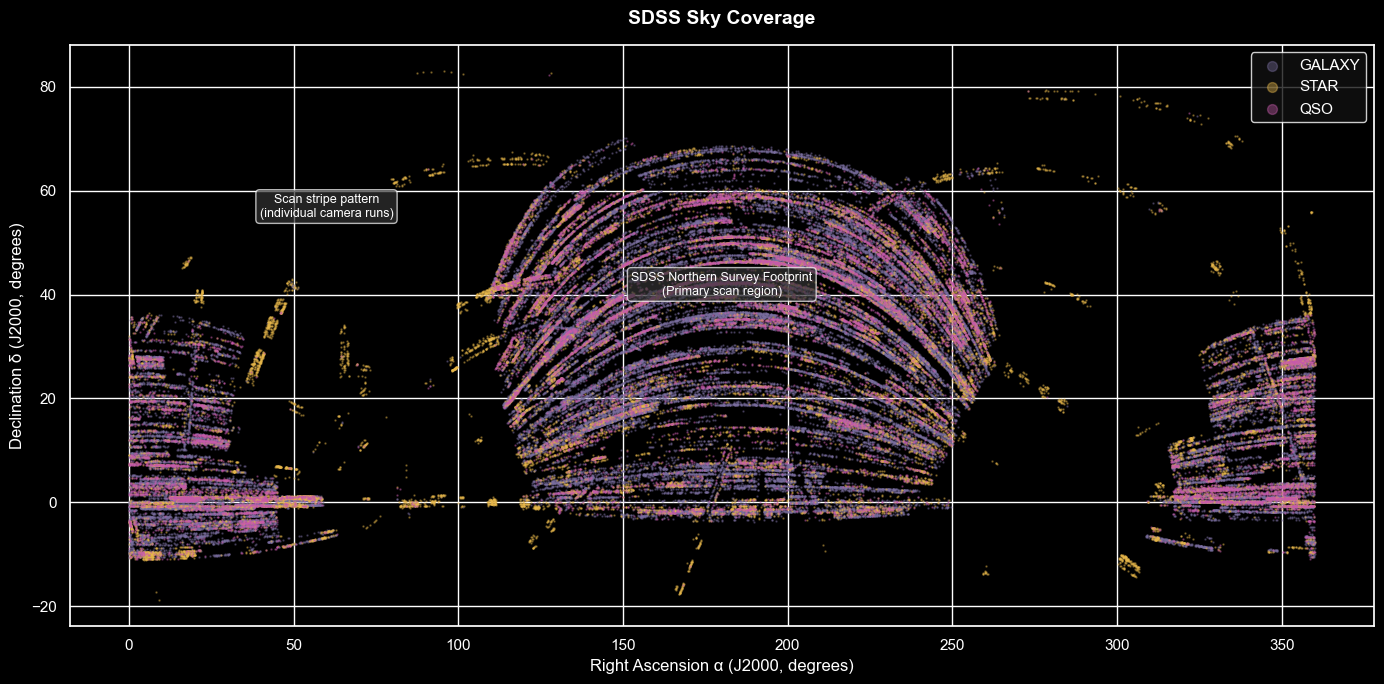

In [160]:
# Sky map, demonstrating spatial distribution of objects
fig, ax = plt.subplots(figsize=(14, 7), facecolor='black')
ax.set_facecolor('black')

for cls, colour in palette.items():
    subset = df[df['class'] == cls]
    ax.scatter(subset['alpha'], subset['delta'],
               c=colour, label=cls, s=0.5, alpha=0.4)

ax.annotate('SDSS Northern Survey Footprint\n(Primary scan region)',
            xy=(180, 40), fontsize=9, color='white',
            ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#333333', 
                      edgecolor='white', alpha=0.7))

ax.annotate('Scan stripe pattern\n(individual camera runs)',
            xy=(60, 55), fontsize=9, color='white',
            ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#333333',
                      edgecolor='white', alpha=0.7))

ax.set_title('SDSS Sky Coverage',
             fontsize=14, fontweight='bold', color='white', pad=15)
ax.set_xlabel('Right Ascension α (J2000, degrees)', fontsize=12, color='white')
ax.set_ylabel('Declination δ (J2000, degrees)', fontsize=12, color='white')

ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('white')

legend = ax.legend(markerscale=10, fontsize=11, 
                   facecolor='#111111', edgecolor='white',
                   labelcolor='white')

plt.tight_layout()
plt.show()

## SDSS Sky Coverage Map

The graph above demonstrates the positioning of all analysed datapoints in what's known as a Sky Map. The y-axis, labeled declination δ, is measured in degrees north and south of the celestial equation. The x-axis, labeled right ascension α, is measured east from the equinox. The standard astronomical epoch and equinox, J2000, is used as a coordinate reference frame anchored to the 1st of January 2000 at 12:00 TT. Earth's axial precession means coordinate systems drift over time, so a standard frame ensures all observations are referenced consistently regardless of when they were taken. 

Two key features of the SDSS include:

1. The main survey footprint (α 100°–260°, δ 0°–60°)
2. The smaller, secondary patch (α 300°–360° and α 0°–50°)

A full celestial equator scan is also evident, demonstrated by the horizontal stripe at δ ≈ 0°. Furthermore, stars are seemingly more scattered across the full sky compared to other object classes. By the nature of their distribution throughout the Milky Way, stars are observed more incidentally across all SDSS pointings, explaining their broader spatial spread. 




## Summary

The analysis above pertains to data collected by the Sloan Digital Sky Survey DR17, sourced from Kaggle (fedesoriano, 2022). Here, 100,000 observations of space were taken, describing 17 distinct features as well as class categorisation. 

The data is initially inspected, ensuring all values within the work agree with expected notation and values. Preliminary analysis is conducted, viewing the initial class distribution as well as the presence of any null/extreme values through descriptive statistics. Sentinel values of -9999.0 were identified in photometric filters u, g, and z across a single observation. Cross-referencing coordinates (α=224.006°, δ=-0.624°) against the SDSS SkyServer database identified the object as SDSS J145601.56-003727.4, observed on 21st March 1999. The EDGE imaging flag confirmed the object was captured at the boundary of a camera field, physically explaining the simultaneous filter failures. The observation was removed from the working dataset.

Once vetted, the data is transformed to prepare it for analysis of physical properties and distributions. Graphs are plotted, visualising class distribution across the set, redshift variations, magnitude of respective photometric filters, and an overall sky coverage map illustrating the spatial distribution of objects in the dataset. 

The dataset exhibited a moderate class imbalance, with galaxies comprising 59.4% of observations. Stars and quasars accounted for 21.6% and 19.0% respectively. 

Redshift proved the strongest discriminator between object classes. Stars clustered sharply at z ≈ 0, consistent with their location within the Milky Way and negligible recession velocity relative to the observer. Galaxies exhibited a bimodal distribution with peaks at z ≈ 0.1 and z ≈ 0.4, reflecting the SDSS's deliberate targeting of two distinct populations, those being the Main Galaxy Sample and the Luminous Red Galaxy sample. Quasars showed a broad distribution peaking at z ≈ 1.3 and extending to z ≈ 7, consistent with their status as some of the most ancient and distant objects in the observable universe. The stellar spike required y-axis clipping to reveal the underlying galaxy and quasar distributions.

Photometric analysis demonstrated the distinction between apparent and intrinsic magnitude. Stars were brightest across most filters, particularly in ultraviolet, reflecting the prevalence of hot, UV-luminous stellar types in the sample. Galaxies were faintest in ultraviolet, consistent with older stellar populations that emit poorly at short wavelengths. Quasars, despite being intrinsically the most luminous objects in the universe, appeared faintest across most filters due to their sheer distance. This demonstrates the distinction between intrinsic luminosity and apparent magnitude as described by the distance modulus equation.

Finally, the sky coverage map revealed the SDSS northern survey footprint concentrated between α 100°–260° and δ 0°–60°. Individual camera scan stripes were clearly visible within the primary footprint, reflecting the telescope's drift-scanning observation strategy. A secondary survey region straddling the 0°/360° right ascension meridian appeared as two isolated patches. This is the result of mapping circular coordinates onto a flat rectangular grid. A separate equatorial scan was evident at δ≈0°. Stars were notably more spatially uniform than galaxies and quasars, as stellar observations were not confined to the targeted spectroscopic footprint.

## Further Work 

The redshift and photometric features identified as strong class discriminators provide a solid foundation for supervised classification modelling. A Random Forest or Logistic Regression classifier trained on these features would naturally follow from this EDA. Further domain insight could be gained through colour index analysis, deriving magnitude differences between adjacent filters which are physically meaningful quantities widely used in stellar classification. Temporal analysis using the Modified Julian Date column could reveal whether the survey's object type distribution shifted over the course of the observation programme.